In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Hitters dataset direct URL se load karein
url = "https://raw.githubusercontent.com/selva86/datasets/master/Hitters.csv"
df = pd.read_csv(url)

# # Missing salaries wali rows drop karein (zaroori step)
# df = df.dropna()

# Categorical columns ko One-Hot Encode karein
df = pd.get_dummies(df, drop_first=True)

# Apne system par save kar lein
df.to_csv("Hitters_cleaned.csv", index=False)

In [53]:
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
0,293,66,1,30,29,14,1,293,66,1,30,29,14,446,33,20,NaN,False,False,False
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,True,False,True


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AtBat        322 non-null    int64  
 1   Hits         322 non-null    int64  
 2   HmRun        322 non-null    int64  
 3   Runs         322 non-null    int64  
 4   RBI          322 non-null    int64  
 5   Walks        322 non-null    int64  
 6   Years        322 non-null    int64  
 7   CAtBat       322 non-null    int64  
 8   CHits        322 non-null    int64  
 9   CHmRun       322 non-null    int64  
 10  CRuns        322 non-null    int64  
 11  CRBI         322 non-null    int64  
 12  CWalks       322 non-null    int64  
 13  PutOuts      322 non-null    int64  
 14  Assists      322 non-null    int64  
 15  Errors       322 non-null    int64  
 16  Salary       263 non-null    float64
 17  League_N     322 non-null    bool   
 18  Division_W   322 non-null    bool   
 19  NewLeagu

In [55]:
df.isna().sum()

AtBat           0
Hits            0
HmRun           0
Runs            0
RBI             0
Walks           0
Years           0
CAtBat          0
CHits           0
CHmRun          0
CRuns           0
CRBI            0
CWalks          0
PutOuts         0
Assists         0
Errors          0
Salary         59
League_N        0
Division_W      0
NewLeague_N     0
dtype: int64

In [56]:
# drop Missing salaries rows (important step)
df = df.dropna()

In [57]:
df.isna().sum()

AtBat          0
Hits           0
HmRun          0
Runs           0
RBI            0
Walks          0
Years          0
CAtBat         0
CHits          0
CHmRun         0
CRuns          0
CRBI           0
CWalks         0
PutOuts        0
Assists        0
Errors         0
Salary         0
League_N       0
Division_W     0
NewLeague_N    0
dtype: int64

In [58]:
#  One-Hot Encode on Categorical columns
df = pd.get_dummies(df, drop_first=True)

In [59]:
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,False,True,False


In [60]:
# save on system
df.to_csv("Hitters_cleaned.csv", index=False)

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNetCV

X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# automatically find best alpha by lasso CV
from sklearn.linear_model import RidgeCV, LassoCV
alphas_range = np.logspace(-3, 2, 100)

# Baseline: Linear Regression (No alpha tuning)
lr = LinearRegression().fit(X_train_scaled, y_train)

# Tuned Ridge
ridge_cv = RidgeCV(alphas=alphas_range, cv=5).fit(X_train_scaled, y_train)

# Tuned Lasso
lasso_cv = LassoCV(alphas=alphas_range, cv=5, random_state=42, max_iter=10000).fit(
    X_train_scaled, y_train
)

# Tuned ElasticNet
elastic_cv = ElasticNetCV(
    alphas=alphas_range,
    l1_ratio=[0.1, 0.5, 0.7, 0.9],
    cv=5,
    random_state=42,
    max_iter=10000,
).fit(X_train_scaled, y_train)

# Models
alpha_ridge = ridge_cv.alpha_
alpha_lasso = lasso_cv.alpha_
aplha_elastic = elastic_cv.alpha_
lr = LinearRegression().fit(X_train_scaled, y_train)
ridge = Ridge(alpha=alpha_ridge).fit(X_train_scaled, y_train)
lasso = Lasso(alpha=alpha_lasso).fit(X_train_scaled, y_train)
elastic = ElasticNet(alpha=aplha_elastic, l1_ratio=0.6).fit(X_train_scaled, y_train)

# Check karein kitne features zero hue
print("LinearRegression ne kitne zero kiye:", np.sum(lr.coef_ == 0))
print("Lasso ne kitne zero kiye:", np.sum(lasso.coef_ == 0))
print("Ridge ne kitne zero kiye:", np.sum(ridge.coef_ == 0))  # Yeh hamesha 0 aayega
print("ElasticNet ne kitne zero kiye:", np.sum(elastic.coef_ == 0))

LinearRegression ne kitne zero kiye: 0
Lasso ne kitne zero kiye: 13
Ridge ne kitne zero kiye: 0
ElasticNet ne kitne zero kiye: 1


In [76]:
lasso_cv.alpha_

np.float64(24.77076355991709)

In [77]:
# R2 score of both 4 models
y_pred_lr = lr.predict(X_test_scaled)
y_pred_ridge = ridge_cv.predict(X_test_scaled)
y_pred_lasso = lasso_cv.predict(X_test_scaled)
y_pred_elastic = elastic_cv.predict(X_test_scaled)

print("=== Optimal Parameters Found ===")
print(f"Best Ridge Alpha:     {ridge_cv.alpha_:.4f}")
print(f"Best Lasso Alpha:     {lasso_cv.alpha_:.4f}")
print(
    f"Best ElasticNet Alpha:{elastic_cv.alpha_:.4f} (l1_ratio: {elastic_cv.l1_ratio_})"
)

print("\n=== R2 Scores on Test Set ===")
print(f"Linear Regression:    {r2_score(y_test, y_pred_lr):.4f}")
print(f"Tuned Ridge:          {r2_score(y_test, y_pred_ridge):.4f}")
print(f"Tuned Lasso:          {r2_score(y_test, y_pred_lasso):.4f}")
print(f"Tuned ElasticNet:     {r2_score(y_test, y_pred_elastic):.4f}")



=== Optimal Parameters Found ===
Best Ridge Alpha:     100.0000
Best Lasso Alpha:     24.7708
Best ElasticNet Alpha:0.5995 (l1_ratio: 0.1)

=== R2 Scores on Test Set ===
Linear Regression:    0.2907
Tuned Ridge:          0.1900
Tuned Lasso:          0.2094
Tuned ElasticNet:     0.1893


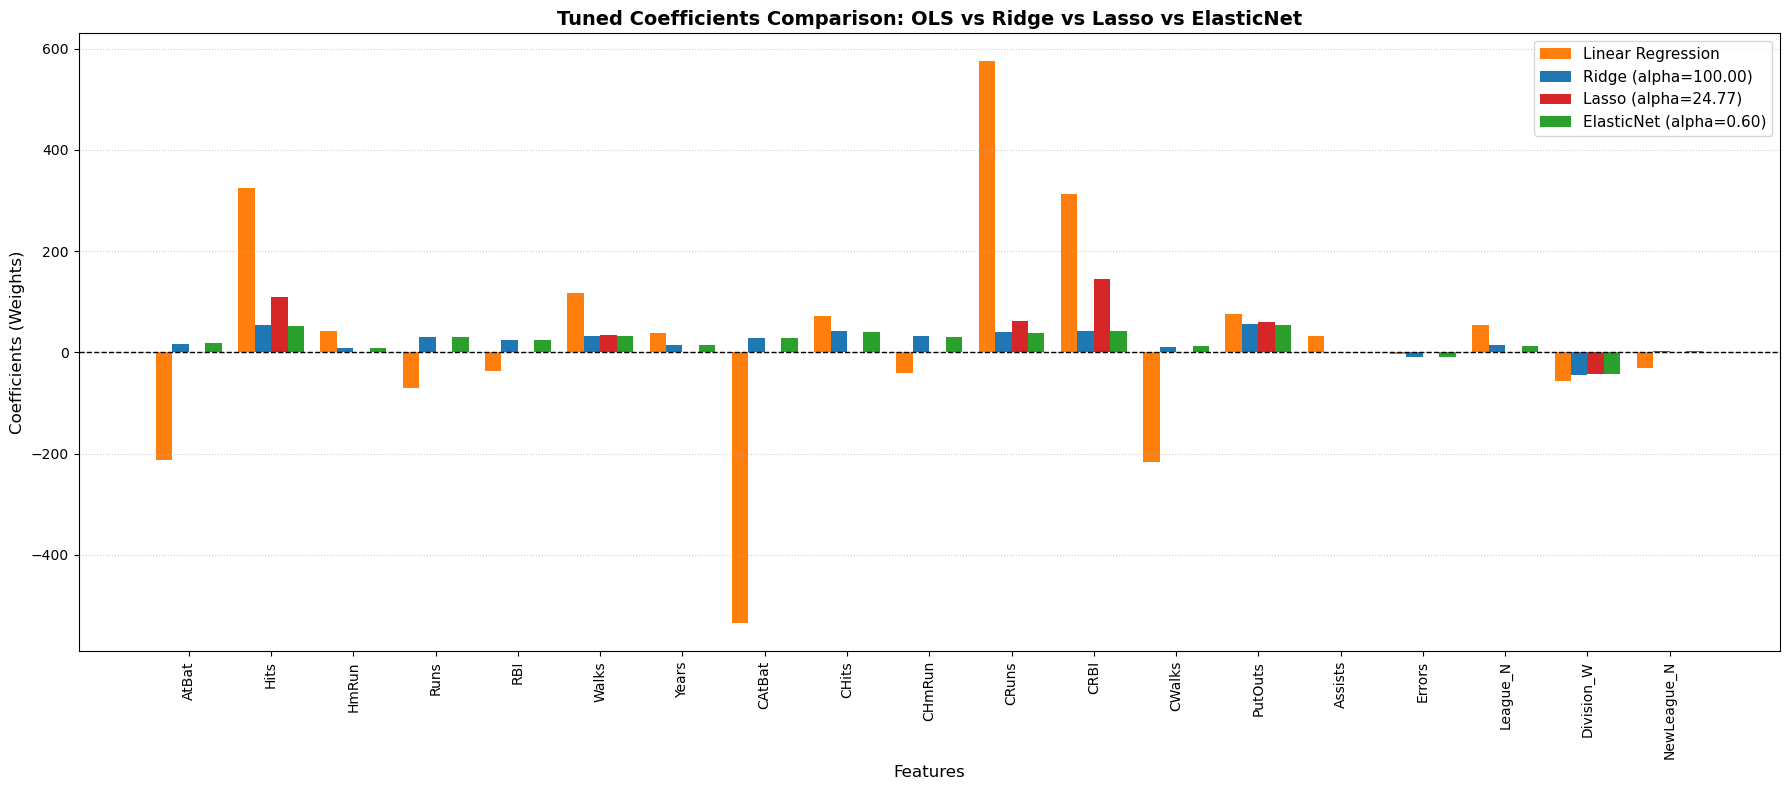

In [78]:
features = X.columns
x_indices = np.arange(len(features))
bar_width = 0.20

plt.figure(figsize=(18, 8))

# Bars
plt.bar(
    x_indices - 1.5 * bar_width,
    lr.coef_,
    width=bar_width,
    label="Linear Regression",
    color="#ff7f0e",
)
plt.bar(
    x_indices - 0.5 * bar_width,
    ridge_cv.coef_,
    width=bar_width,
    label=f"Ridge (alpha={ridge_cv.alpha_:.2f})",
    color="#1f77b4",
)
plt.bar(
    x_indices + 0.5 * bar_width,
    lasso_cv.coef_,
    width=bar_width,
    label=f"Lasso (alpha={lasso_cv.alpha_:.2f})",
    color="#d62728",
)
plt.bar(
    x_indices + 1.5 * bar_width,
    elastic_cv.coef_,
    width=bar_width,
    label=f"ElasticNet (alpha={elastic_cv.alpha_:.2f})",
    color="#2ca02c",
)

# Visual lines & Styling
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xticks(x_indices, features, rotation=90, fontsize=10)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Coefficients (Weights)", fontsize=12)
plt.title(
    "Tuned Coefficients Comparison: OLS vs Ridge vs Lasso vs ElasticNet",
    fontsize=14,
    fontweight="bold",
)
plt.legend(fontsize=11)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()

plt.show()